# FP-Cox Optimizer — SaDE v5

Self-Adaptive Differential Evolution for Fractional Polynomial Cox model selection.

See the module docstring below for a full list of fixes applied vs v4.

In [1]:
"""
FP-Cox Optimizer — SaDE v5
==========================
Fixes applied vs v4
--------------------
FIX 1  (Critical / theoretical+numerical)
    _preprocess_positive now SCALES each covariate by the nearest power-of-10
    to its mean absolute value, following Royston & Sauerbrei §2.3.
    Without this, extreme powers (−3, −2) produce coefficients in the
    thousands (e.g. Age_fp_-2 = −2781 in v4), distorting the BIC surface
    and the ridge penaliser.  Scale factors are stored in self._scales so
    new observations can be transformed consistently.

FIX 2  (High / theoretical)
    BIC now uses n_events (number of observed events) instead of n (total
    observations) as the sample-size term.  The Cox partial likelihood
    conditions only on event times; censored rows do not contribute a
    likelihood term, so n_events is the correct effective sample size.
    Consistent with R's extractAIC.coxph default.

FIX 3  (Moderate / theoretical)
    BIC is now computed from the UNPENALIZED partial log-likelihood.
    lifelines returns the *penalized* log-likelihood when penalizer > 0,
    which makes the BIC formula theoretically invalid (BIC is defined for
    MLE, not MAP estimators).  We fit a second, unpenalized model purely
    to extract the true log-likelihood for BIC; the penalized model is
    kept for all other purposes (coefficients, IBS, C-index).

FIX 4  (Low / comment)
    _s2 relabelled from "DE/rand-to-best/2" to the correct
    "DE/current-to-best/2".  The formula starts from pop[t] (current
    individual), not a random vector.

FIX 5  (Low / documentation)
    F~Cauchy(0.5, 0.3) is a JADE-style extension (Zhang & Sanderson 2009),
    not part of original SaDE (Qin, Huang & Suganthan 2009) which uses
    fixed F=0.5.  Documented explicitly in the class docstring.

FIX 6  (Low / theoretical)
    CRM updated via MEAN of successful CRs (original SaDE paper), not
    median.  Median is more robust but deviates from the paper's spec.

FIX 7  (Low / implementation)
    _s2 now excludes BOTH t (current) and b (best) when sampling the four
    random difference vectors, preventing the best individual from appearing
    twice in the same mutation formula.
    _choose updated to accept a list or a single int for excl.

FIX 8  (Low / code consistency)
    The v4 comment claimed log_er was "removed" from GB_COVARIATES, while
    the column was still in the list and IS present in preprocess_gbsg.csv.
    The misleading comment has been removed; log_er is kept as a covariate.

FIX 9  (Moderate / methodological)
    _compute_ibs now accepts optional train/test split arguments.
    When only training data is available, a warning is printed so the
    reported IBS is never silently interpreted as a test-set estimate.

FIX 10 (Trivial / naming)
    Warm-start constant renamed  SQ = SQRT  (index 10 = power 0.5).
"""

'\nFP-Cox Optimizer — SaDE v5\n==========================\nFixes applied vs v4\n--------------------\nFIX 1  (Critical / theoretical+numerical)\n    _preprocess_positive now SCALES each covariate by the nearest power-of-10\n    to its mean absolute value, following Royston & Sauerbrei §2.3.\n    Without this, extreme powers (−3, −2) produce coefficients in the\n    thousands (e.g. Age_fp_-2 = −2781 in v4), distorting the BIC surface\n    and the ridge penaliser.  Scale factors are stored in self._scales so\n    new observations can be transformed consistently.\n\nFIX 2  (High / theoretical)\n    BIC now uses n_events (number of observed events) instead of n (total\n    observations) as the sample-size term.  The Cox partial likelihood\n    conditions only on event times; censored rows do not contribute a\n    likelihood term, so n_events is the correct effective sample size.\n    Consistent with R\'s extractAIC.coxph default.\n\nFIX 3  (Moderate / theoretical)\n    BIC is now computed 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
import warnings
from collections import deque
from dataclasses import dataclass, field
from typing import List, Optional, Union

warnings.filterwarnings('ignore')

try:
    from sksurv.metrics import integrated_brier_score
    from sksurv.util import Surv
    HAS_SKSURV = True
except ImportError:
    HAS_SKSURV = False
    print('scikit-survival not found — IBS skipped.')

In [3]:
# ---------------------------------------------------------------------------
# Result container
# ---------------------------------------------------------------------------

@dataclass
class _SaDEResult:
    x:       np.ndarray
    fun:     float
    nfev:    int
    ngen:    int
    history: List[float] = field(default_factory=list)

In [4]:
# ---------------------------------------------------------------------------
# FIX 7: _choose accepts int OR list for excl
# ---------------------------------------------------------------------------

def _choose(n: int, k: int, excl: Union[int, list], rng) -> np.ndarray:
    mask = np.ones(n, dtype=bool)
    if isinstance(excl, int):
        excl = [excl]
    for e in excl:
        mask[e] = False
    pool = np.where(mask)[0]
    if len(pool) < k:
        # Fallback: sample with replacement if population too small
        return rng.choice(pool, size=k, replace=True)
    return rng.choice(pool, size=k, replace=False)

In [5]:
# ---------------------------------------------------------------------------
# Mutation strategies
# FIX 4: _s2 label corrected to DE/current-to-best/2
# FIX 7: _s2 excludes both t and b
# ---------------------------------------------------------------------------

def _s1(pop, F, t, b, rng):                          # DE/rand/1
    r1, r2, r3 = _choose(len(pop), 3, t, rng)
    return pop[r1] + F * (pop[r2] - pop[r3])


def _s2(pop, F, t, b, rng):                          # DE/current-to-best/2  (FIX 4)
    # FIX 7: exclude both current (t) and best (b) from random vectors
    r1, r2, r3, r4 = _choose(len(pop), 4, [t, b], rng)
    return (pop[t]
            + F * (pop[b]  - pop[t])
            + F * (pop[r1] - pop[r2])
            + F * (pop[r3] - pop[r4]))


def _s3(pop, F, t, b, rng):                          # DE/current-to-rand/1
    r1, r2, r3 = _choose(len(pop), 3, t, rng)
    return pop[t] + F * (pop[r1] - pop[t]) + F * (pop[r2] - pop[r3])


def _s4(pop, F, t, b, rng):                          # DE/rand/2
    r1, r2, r3, r4, r5 = _choose(len(pop), 5, t, rng)
    return pop[r1] + F * (pop[r2] - pop[r3]) + F * (pop[r4] - pop[r5])


_STRATS = [_s1, _s2, _s3, _s4]
_NS     = len(_STRATS)

In [6]:
# ---------------------------------------------------------------------------
# Boundary repair and binomial crossover
# ---------------------------------------------------------------------------

def _repair(v: np.ndarray, lb: np.ndarray, ub: np.ndarray) -> np.ndarray:
    v = np.round(v).astype(int)
    lo = v < lb
    v[lo] = lb[lo] + (lb[lo] - v[lo])   # reflection
    hi = v > ub
    v[hi] = ub[hi] - (v[hi] - ub[hi])   # reflection
    return np.clip(v, lb, ub)


def _cross(x: np.ndarray, v: np.ndarray, CR: float, rng) -> np.ndarray:
    d = len(x)
    m = rng.random(d) < CR
    m[rng.integers(d)] = True            # guarantee at least one dimension
    return np.where(m, v, x)


In [7]:
# ---------------------------------------------------------------------------
# SaDE engine
# FIX 5: F~Cauchy documented as JADE-style extension
# FIX 6: CRM updated via mean (original SaDE spec)
# ---------------------------------------------------------------------------

class _SaDE:
    """
    Self-Adaptive Differential Evolution engine for integer search spaces.

    Strategy pool
    -------------
    _s1  DE/rand/1
    _s2  DE/current-to-best/2
    _s3  DE/current-to-rand/1
    _s4  DE/rand/2

    Adaptation rules (original SaDE — Qin, Huang & Suganthan 2009)
    ---------------------------------------------------------------
    Strategy probabilities: updated every lp generations via
        p_k  ∝  0.05 + 0.95 * ns_k / (ns_k + nf_k)
    CRM (mean CR per strategy): updated every lp generations via
        crm_k  =  mean(successful CRs in sliding window of size lp)
        [FIX 6: mean, not median — median was used in v4]

    Scale-factor F
    --------------
    F ~ Cauchy(0.5, 0.3), clipped to (0, 2].
    NOTE (FIX 5): this is a JADE-style extension (Zhang & Sanderson 2009).
    Original SaDE uses fixed F=0.5.  The Cauchy draw is kept here because
    it improves exploration on discrete integer spaces, but it should be
    acknowledged as a deviation from the strict SaDE specification.
    """

    def __init__(self, func, bounds, pop_size=50, max_evals=1000,
                 lp=10, patience=10, seed=None, callback=None):
        self.func     = func
        self.bounds   = bounds
        self.dim      = len(bounds)
        self.lb       = np.array([b[0] for b in bounds], dtype=int)
        self.ub       = np.array([b[1] for b in bounds], dtype=int)
        self.N        = pop_size
        self.maxev    = max_evals
        self.lp       = lp
        self.patience = patience
        self.cb       = callback
        self.rng      = np.random.default_rng(seed)
        self.p        = np.ones(_NS) / _NS
        self.crm      = np.full(_NS, 0.5)
        self.ns       = [deque() for _ in range(_NS)]
        self.nf       = [deque() for _ in range(_NS)]
        self.crok     = [deque() for _ in range(_NS)]

    def run_opt(self, init_pop: Optional[np.ndarray] = None) -> _SaDEResult:
        if (init_pop is not None
                and init_pop.shape == (self.N, self.dim)):
            pop = np.clip(np.round(init_pop).astype(int), self.lb, self.ub)
        else:
            pop = self.rng.integers(self.lb, self.ub + 1,
                                    size=(self.N, self.dim))

        fit        = np.array([self.func(pop[i]) for i in range(self.N)])
        nfev       = self.N
        bi         = int(np.argmin(fit))
        hist       = [float(fit[bi])]
        gen        = 0
        no_improve = 0
        best_ever  = float(fit[bi])

        while nfev < self.maxev:
            gen += 1
            for i in range(self.N):
                if nfev >= self.maxev:
                    break
                k  = self.rng.choice(_NS, p=self.p)
                # FIX 5 NOTE: Cauchy F is JADE-style, not original SaDE
                F  = float(np.clip(
                        self.rng.standard_cauchy() * 0.3 + 0.5, 1e-6, 2.0))
                CR = float(np.clip(
                        self.rng.normal(self.crm[k], 0.1), 0.0, 1.0))
                v  = _STRATS[k](pop, F, i, bi, self.rng).astype(float)
                u  = _repair(
                        _cross(pop[i].astype(float), v, CR, self.rng),
                        self.lb, self.ub)
                fu = self.func(u)
                nfev += 1
                if fu <= fit[i]:
                    pop[i], fit[i] = u, fu
                    self.ns[k].append(1)
                    self.crok[k].append(CR)
                    if fu < fit[bi]:
                        bi = i
                else:
                    self.nf[k].append(1)

            if gen % self.lp == 0:
                self._upd_p()
                self._upd_crm()

            hist.append(float(fit[bi]))
            if self.cb:
                self.cb(pop[bi], fit[bi], gen)

            if self.patience > 0:
                if fit[bi] < best_ever - 1e-8:
                    best_ever  = float(fit[bi])
                    no_improve = 0
                else:
                    no_improve += 1
                if no_improve >= self.patience:
                    print(f'  Early stop at gen {gen} '
                          f'(no improvement for {self.patience} gens, '
                          f'evals used: {nfev})')
                    break

        return _SaDEResult(x=pop[bi].copy(), fun=float(fit[bi]),
                           nfev=nfev, ngen=gen, history=hist)

    def _upd_p(self):
        ns  = np.array([sum(q) for q in self.ns], dtype=float)
        nf  = np.array([sum(q) for q in self.nf], dtype=float)
        with np.errstate(divide='ignore', invalid='ignore'):
            r = np.where(ns + nf > 0, ns / (ns + nf), 0.0)
        tot = r.sum()
        if tot > 0:
            self.p = 0.05 + 0.95 * r / tot
            self.p /= self.p.sum()
        for k in range(_NS):
            while len(self.ns[k]) > self.lp:
                self.ns[k].popleft()
            while len(self.nf[k]) > self.lp:
                self.nf[k].popleft()

    def _upd_crm(self):
        # FIX 6: use mean (original SaDE spec), not median (v4 deviation)
        for k in range(_NS):
            if self.crok[k]:
                self.crm[k] = float(np.mean(list(self.crok[k])))
            while len(self.crok[k]) > self.lp:
                self.crok[k].popleft()


print('SaDE v5 engine loaded.')

SaDE v5 engine loaded.


In [8]:
# ---------------------------------------------------------------------------
# FPCoxOptimizer v5
# ---------------------------------------------------------------------------

class FPCoxOptimizer:
    """
    FP-Cox Optimizer v5.

    Searches for the optimal fractional polynomial power combination for
    each covariate using Self-Adaptive Differential Evolution (SaDE), then
    fits a Cox proportional hazards model on the transformed covariates.

    Parameters
    ----------
    df           : pandas DataFrame  (training data)
    covariates   : list of continuous covariate column names to FP-transform
    duration_col : name of the survival time column
    event_col    : name of the event indicator column (1=event, 0=censored)
    penalizer    : ridge penalizer passed to lifelines CoxPHFitter (default 0.01)
    gamma        : c-index weight in the objective:
                   objective = BIC_unpenalized − gamma × n_events × C-index
                   Set gamma=0 for pure BIC minimisation.
    strata_cols  : covariates to stratify on (for PH-violating variables)
    df_test      : optional held-out test DataFrame for unbiased IBS
                   (FIX 9: if None, IBS is evaluated on training data with
                   a printed warning)
    """

    POWER_SET = [None, -3, -2.5, -2, -1.5, -1, -0.5, -0.25,
                 0,    0.25, 0.5, 1,  1.5,  2,  2.5,  3]
    N_POWERS  = len(POWER_SET)   # 16

    def __init__(self, df, covariates, duration_col, event_col,
                 penalizer=0.01, gamma=0.0, strata_cols=None,
                 df_test=None):

        self.covariates   = covariates
        self.duration_col = duration_col
        self.event_col    = event_col
        self.penalizer    = penalizer
        self.gamma        = gamma
        self.strata_cols  = strata_cols or []

        # FIX 1: shift + scale; stores scale factors for test-set use
        self.df, self._scales = self._preprocess_positive(df, covariates)

        # FIX 9: optional test set (scaled consistently with training)
        if df_test is not None:
            self.df_test, _ = self._preprocess_positive(
                df_test, covariates, scales=self._scales)
        else:
            self.df_test = None

        # FIX 2: n_events for BIC penalty
        self._n_events = int(self.df[self.event_col].sum())

        # Precompute all 16 power transforms for each covariate once
        self._precomp = {}      # (col, power) = np.ndarray
        self._log_x   = {}      # col = np.log(x)
        for col in covariates:
            x     = self.df[col].values.astype(float)
            log_x = np.log(x)
            self._log_x[col] = log_x
            for p in [p for p in self.POWER_SET if p is not None]:
                z = log_x if p == 0 else np.power(x, p)
                if np.isfinite(z).all():
                    self._precomp[(col, p)] = z

        # Pre-build the constant skeleton DataFrame (duration + event + strata)
        const_cols = {
            self.duration_col: self.df[self.duration_col].values,
            self.event_col:    self.df[self.event_col].values,
        }
        for c in self.strata_cols:
            const_cols[c] = self.df[c].values
        self._const_df = pd.DataFrame(const_cols, index=self.df.index)

        self.evaluation_cache  = {}
        self.best_val          = np.inf
        self.history: list     = []
        self.best_powers: list = []
        self.final_fp_model    = None
        self.traditional_model = None
        self.metrics_: dict    = {}
        self._df_trad_final    = None
        self._df_fp_final      = None

    # -----------------------------------------------------------------------
    # FIX 1: shift AND scale preprocessing
    # -----------------------------------------------------------------------

    @staticmethod
    def _preprocess_positive(df, features, scales=None):
        """
        For each feature:
          1. Shift so all values are strictly positive (min = 1e-5).
          2. Scale by the nearest power-of-10 to the mean absolute value
             (Royston & Sauerbrei §2.3) to keep transformed values in a
             numerically comfortable range.

        Returns (processed_df, scale_dict).  Pass scale_dict back in the
        `scales` argument to apply the same transformation to test data.
        """
        df = df.copy()
        computed_scales = {}

        for col in features:
            x = df[col].astype(float)

            # Step 1: shift to positivity
            if (x <= 0).any():
                x = x - x.min() + 1e-5

            # Step 2: scale
            if scales is not None:
                # Apply pre-computed scale from training data
                scale = scales[col]
            else:
                mean_abs = np.mean(np.abs(x))
                if mean_abs == 0:
                    scale = 1.0
                else:
                    # Nearest power of 10 to mean absolute value
                    scale = 10.0 ** np.floor(np.log10(mean_abs))

            computed_scales[col] = scale
            df[col] = x / scale

        return df, computed_scales

    # -----------------------------------------------------------------------
    # Cache key: order-invariant within each covariate pair
    # -----------------------------------------------------------------------

    @staticmethod
    def _canonical_key(indices):
        key = list(indices)
        for i in range(0, len(key), 2):
            a, b = key[i], key[i + 1]
            if b == 0 and a != 0:           # NA always first
                key[i], key[i + 1] = 0, a
            elif a != 0 and b != 0:         # smaller index first
                key[i], key[i + 1] = min(a, b), max(a, b)
        return tuple(key)

    # -----------------------------------------------------------------------
    # FP feature builder (uses precomputed arrays)
    # -----------------------------------------------------------------------

    def _generate_fp_features(self, features, powers):
        """
        Returns dict {col_name: array} or None if any transform is invalid.
        Powers is a list of (p1, p2) tuples aligned with features.
        Repeated-power case: H1 = x^p, H2 = x^p * ln(x).
        """
        transformed = {}
        for col, (p1, p2) in zip(features, powers):
            active = sorted([p for p in (p1, p2) if p is not None])
            if not active:
                continue
            if len(active) == 1:
                p   = active[0]
                arr = self._precomp.get((col, p))
                if arr is None:
                    return None
                transformed[f'{col}_fp_{p}'] = arr
            else:
                pa, pb = active
                za = self._precomp.get((col, pa))
                if za is None:
                    return None
                transformed[f'{col}_fp1_{pa}'] = za
                if pa == pb:
                    # Repeated power: second term is x^p * ln(x)
                    transformed[f'{col}_fp2_rep_{pb}'] = za * self._log_x[col]
                else:
                    zb = self._precomp.get((col, pb))
                    if zb is None:
                        return None
                    transformed[f'{col}_fp2_{pb}'] = zb
        return transformed

    # -----------------------------------------------------------------------
    # FIX 2 + FIX 3: objective function with corrected BIC
    # -----------------------------------------------------------------------

    def _objective_function(self, x):
        key = self._canonical_key(x)
        if key in self.evaluation_cache:
            return self.evaluation_cache[key]

        powers = [
            (self.POWER_SET[key[2 * i]], self.POWER_SET[key[2 * i + 1]])
            for i in range(len(self.covariates))
        ]

        fp_cols = self._generate_fp_features(self.covariates, powers)
        if not fp_cols:
            self.evaluation_cache[key] = 1e10
            return 1e10

        df_model = self._const_df.copy()
        for col_name, arr in fp_cols.items():
            df_model[col_name] = arr

        strata = self.strata_cols or None

        try:
            # FIX 3: fit unpenalized model to get the true log-likelihood for BIC
            cph_unpen = CoxPHFitter(penalizer=0.0)
            cph_unpen.fit(df_model,
                          duration_col  = self.duration_col,
                          event_col     = self.event_col,
                          strata        = strata,
                          show_progress = False)

            # FIX 2: use n_events, not n, as the BIC sample-size term
            k   = len(cph_unpen.params_)
            bic = (-2 * cph_unpen.log_likelihood_
                   + k * np.log(self._n_events))

            # C-index from penalized model (more stable with small datasets)
            if self.gamma > 0:
                cph_pen = CoxPHFitter(penalizer=self.penalizer)
                cph_pen.fit(df_model,
                            duration_col  = self.duration_col,
                            event_col     = self.event_col,
                            strata        = strata,
                            show_progress = False)
                ci = cph_pen.concordance_index_
            else:
                ci = 0.0

            val = bic - self.gamma * self._n_events * ci

        except Exception:
            val = 1e10

        self.evaluation_cache[key] = val
        if val < self.best_val:
            self.best_val = val
        return val

    # -----------------------------------------------------------------------
    # FIX 10: warm-start seeds (SQ renamed to SQRT)
    # -----------------------------------------------------------------------

    def _warm_start_pop(self, pop_size, rng):
        dim  = 2 * len(self.covariates)
        pop  = rng.integers(0, self.N_POWERS, size=(pop_size, dim))
        NA, LIN, SQRT, LG, Q = 0, 11, 10, 8, 13  # FIX 10: SQ = SQRT
        seeds = [
            np.tile([LIN,  NA],   len(self.covariates)),  # FP1 linear
            np.tile([SQRT, NA],   len(self.covariates)),  # FP1 sqrt
            np.tile([LG,   NA],   len(self.covariates)),  # FP1 log
            np.tile([LIN,  SQRT], len(self.covariates)),  # FP2 (lin, sqrt)
            np.tile([LIN,  Q],    len(self.covariates)),  # FP2 (lin, quad)
        ]
        for row, s in enumerate(seeds[:min(len(seeds), pop_size)]):
            pop[row] = s
        return pop

    def _callback(self, best_x, best_f, gen):
        self.history.append(self.best_val)

    # -----------------------------------------------------------------------
    # FIX 9: IBS with honest train/test handling
    # -----------------------------------------------------------------------

    def _compute_ibs(self, cph, df_for_model,
                     df_test_model=None, y_test=None):
        """
        Compute Integrated Brier Score.

        If df_test_model and y_test are provided, uses held-out test data
        (unbiased estimate).  Otherwise falls back to training data and
        prints a warning — training-set IBS is optimistic.
        """
        if not HAS_SKSURV:
            return None
        try:
            y_train = Surv.from_arrays(
                event = self.df[self.event_col].astype(bool).values,
                time  = self.df[self.duration_col].values)

            t_min  = self.df[self.duration_col].min()
            t_max  = self.df[self.duration_col].max()
            times  = np.linspace(t_min, t_max * 0.999, 100)

            if df_test_model is not None and y_test is not None:
                # Unbiased test-set IBS
                surv = cph.predict_survival_function(df_test_model,
                                                     times=times)
                return float(integrated_brier_score(
                    y_train, y_test, surv.T.values, times))
            else:
                # FIX 9: training-set fallback — warn the user
                print('  WARNING: IBS computed on training data '
                      '(optimistic). Supply df_test for unbiased estimate.')
                surv = cph.predict_survival_function(df_for_model,
                                                     times=times)
                return float(integrated_brier_score(
                    y_train, y_train, surv.T.values, times))
        except Exception:
            return None

    # -----------------------------------------------------------------------
    # Main entry point
    # -----------------------------------------------------------------------

    def optimize(self, maxiter=15, popsize=8, seed=42, max_evals=None):
        """
        Parameters
        ----------
        maxiter   : maximum generations
        popsize   : population multiplier per dimension
        seed      : RNG seed
        max_evals : total evaluation budget (overrides popsize×dim×maxiter)
        """
        dim      = 2 * len(self.covariates)
        pop_size = popsize * dim

        if max_evals is None:
            max_evals = pop_size * maxiter

        lp       = max(3, maxiter // 5)
        patience = max(3, maxiter // 3)

        print(f'Starting SaDE v5  (gamma={self.gamma})')
        print(f'  FP covariates : {self.covariates}')
        if self.strata_cols:
            print(f'  Strata        : {self.strata_cols}')
        print(f'  Scales applied: '
              + ', '.join(f'{c}÷{s:.3g}' for c, s in self._scales.items()))
        print(f'  n={len(self.df)}, n_events={self._n_events}  '
              f'(BIC uses n_events)')
        print(f'  Pop size      : {pop_size}  |  '
              f'Max gens : {maxiter}  |  '
              f'Budget : {max_evals} evals')
        print(f'  lp (adapt)    : every {lp} gens  |  '
              f'patience (stop) : {patience} gens')
        print(f'  Objective     : ' +
              (f'BIC(unpen) − {self.gamma}·n_events·c-index'
               if self.gamma > 0 else 'BIC(unpenalized) only'))

        rng      = np.random.default_rng(seed)
        init_pop = self._warm_start_pop(pop_size, rng)

        engine = _SaDE(
            func      = self._objective_function,
            bounds    = [(0, self.N_POWERS - 1)] * dim,
            pop_size  = pop_size,
            max_evals = max_evals,
            lp        = lp,
            patience  = patience,
            seed      = seed,
            callback  = self._callback,
        )
        result = engine.run_opt(init_pop=init_pop)

        best_indices = result.x
        print('\n--- Optimal Power Selection ---')
        for i in range(len(self.covariates)):
            p1 = self.POWER_SET[best_indices[2 * i]]
            p2 = self.POWER_SET[best_indices[2 * i + 1]]
            self.best_powers.append((p1, p2))
            print(f'  {self.covariates[i]:<22}: p1={str(p1):<7} p2={p2}')
        if self.strata_cols:
            print(f'  Stratified on : {self.strata_cols}')
        print(f'\n  Best objective : {result.fun:.4f}')
        print(f'  Generations    : {result.ngen}')
        print(f'  Evaluations    : {result.nfev}  '
              f'(cache hits: {result.nfev - len(self.evaluation_cache)})')

        self._plot_convergence()
        self._fit_final_models()

    def _plot_convergence(self):
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, len(self.history) + 1), self.history,
                 marker='o', markersize=3, linestyle='-', color='steelblue')
        title = 'SaDE v5 Convergence'
        if self.strata_cols:
            title += f'  (strata: {self.strata_cols})'
        plt.title(title)
        plt.xlabel('Generation')
        plt.ylabel('BIC(unpen) − γ·n_events·c-index'
                   if self.gamma > 0 else 'BIC (unpenalized)')
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    # -----------------------------------------------------------------------
    # Final model fitting and comparison
    # FIX 2 + FIX 3: BIC uses n_events and unpenalized log-likelihood
    # -----------------------------------------------------------------------

    def _fit_final_models(self):
        print('\n' + '=' * 68)
        print('FINAL MODEL COMPARISON')
        print('=' * 68)

        strata = self.strata_cols or None

        # Build traditional Cox DataFrame (original, pre-FP covariates)
        seen, trad_cols = set(), []
        for c in (self.covariates + self.strata_cols +
                  [self.duration_col, self.event_col]):
            if c not in seen:
                trad_cols.append(c)
                seen.add(c)

        self._df_trad_final = self.df[trad_cols].copy()

        # Penalized model (used for C-index, IBS, coefficients)
        self.traditional_model = CoxPHFitter(penalizer=self.penalizer)
        self.traditional_model.fit(
            self._df_trad_final,
            duration_col  = self.duration_col,
            event_col     = self.event_col,
            strata        = strata,
            show_progress = False)

        # FIX 3: separate unpenalized model for BIC
        _trad_unpen = CoxPHFitter(penalizer=0.0)
        _trad_unpen.fit(
            self._df_trad_final,
            duration_col  = self.duration_col,
            event_col     = self.event_col,
            strata        = strata,
            show_progress = False)

        # FP Cox — build from precomputed transforms
        fp_cols = self._generate_fp_features(self.covariates, self.best_powers)
        if fp_cols is None:
            fp_cols = {}
        self._df_fp_final = self._const_df.copy()
        for col_name, arr in fp_cols.items():
            self._df_fp_final[col_name] = arr

        self.final_fp_model = CoxPHFitter(penalizer=self.penalizer)
        self.final_fp_model.fit(
            self._df_fp_final,
            duration_col  = self.duration_col,
            event_col     = self.event_col,
            strata        = strata,
            show_progress = False)

        _fp_unpen = CoxPHFitter(penalizer=0.0)
        _fp_unpen.fit(
            self._df_fp_final,
            duration_col  = self.duration_col,
            event_col     = self.event_col,
            strata        = strata,
            show_progress = False)

        # FIX 2 + FIX 3: BIC with n_events and unpenalized log-likelihood
        n      = self._n_events
        k_t    = len(_trad_unpen.params_)
        k_fp   = len(_fp_unpen.params_)
        bic_t  = -2 * _trad_unpen.log_likelihood_ + k_t  * np.log(n)
        bic_fp = -2 * _fp_unpen.log_likelihood_   + k_fp * np.log(n)

        ci_t   = self.traditional_model.concordance_index_
        ci_fp  = self.final_fp_model.concordance_index_

        # FIX 9: IBS with test-set awareness
        if self.df_test is not None:
            # Build test-set model DataFrames
            df_test_trad = self.df_test[trad_cols].copy()
            df_test_fp   = self._const_df.iloc[:0].copy()  # just schema
            # Build test fp cols using precomp on training-scaled test data
            test_fp_cols = self._generate_fp_features_on(
                self.df_test, self.covariates, self.best_powers)
            df_test_fp_model = pd.DataFrame(
                {self.duration_col: self.df_test[self.duration_col].values,
                 self.event_col:    self.df_test[self.event_col].values},
                index=self.df_test.index)
            if test_fp_cols:
                for c, a in test_fp_cols.items():
                    df_test_fp_model[c] = a
            for sc in self.strata_cols:
                df_test_fp_model[sc] = self.df_test[sc].values

            y_test = Surv.from_arrays(
                event = self.df_test[self.event_col].astype(bool).values,
                time  = self.df_test[self.duration_col].values
            ) if HAS_SKSURV else None

            ibs_t  = self._compute_ibs(
                self.traditional_model, self._df_trad_final,
                df_test_trad, y_test)
            ibs_fp = self._compute_ibs(
                self.final_fp_model, self._df_fp_final,
                df_test_fp_model, y_test)
        else:
            ibs_t  = self._compute_ibs(
                self.traditional_model, self._df_trad_final)
            ibs_fp = self._compute_ibs(
                self.final_fp_model, self._df_fp_final)

        self.metrics_ = {
            'C-index (trad)' : round(ci_t,   4),
            'C-index (FP)'   : round(ci_fp,  4),
            'BIC (trad)'     : round(bic_t,  2),
            'BIC (FP)'       : round(bic_fp, 2),
            'IBS (trad)' : round(ibs_t, 4) if ibs_t  is not None else 'N/A',
            'IBS (FP)'   : round(ibs_fp,4) if ibs_fp is not None else 'N/A',
            'k (trad)'       : k_t,
            'k (FP)'         : k_fp,
        }

        W = 22
        hdr = (f"\n{'Metric':<25} | {'Traditional Cox':>{W}} "
               f"| {'FP Cox (SaDE v5)':>{W}}")
        print(hdr)
        print('-' * len(hdr))
        print(f"{'Concordance index':<25} | {ci_t:>{W}.4f} | {ci_fp:>{W}.4f}")
        print(f"{'BIC (unpen, n_events)':<25} | {bic_t:>{W}.2f} | {bic_fp:>{W}.2f}")
        if ibs_t is not None and ibs_fp is not None:
            label = 'IBS (test)' if self.df_test is not None else 'IBS (train, optimistic)'
            print(f"{label:<25} | {ibs_t:>{W}.4f} | {ibs_fp:>{W}.4f}")
        print(f"{'Log-lik (unpen)':<25} | "
              f"{_trad_unpen.log_likelihood_:>{W}.4f} | "
              f"{_fp_unpen.log_likelihood_:>{W}.4f}")
        print(f"{'Parameters (k)':<25} | {k_t:>{W}d} | {k_fp:>{W}d}")
        if strata:
            print(f'  * Both models stratified on: {strata}')
        print(f'\n  Covariate scales (divide raw values by these before'
              f' scoring new data):')
        for col, sc in self._scales.items():
            print(f'    {col}: ÷{sc:.4g}')

    def _generate_fp_features_on(self, df, features, powers):
        """
        Compute FP features on an arbitrary DataFrame (e.g. test set) using
        the same power transforms.  Does NOT use the precomp cache (which
        is indexed to training rows); recomputes on the fly.
        """
        transformed = {}
        for col, (p1, p2) in zip(features, powers):
            x     = df[col].values.astype(float)
            log_x = np.log(x)
            active = sorted([p for p in (p1, p2) if p is not None])
            if not active:
                continue

            def xp(p):
                z = log_x if p == 0 else np.power(x, p)
                return z if np.isfinite(z).all() else None

            if len(active) == 1:
                p   = active[0]
                arr = xp(p)
                if arr is None:
                    return None
                transformed[f'{col}_fp_{p}'] = arr
            else:
                pa, pb = active
                za = xp(pa)
                if za is None:
                    return None
                transformed[f'{col}_fp1_{pa}'] = za
                if pa == pb:
                    transformed[f'{col}_fp2_rep_{pb}'] = za * log_x
                else:
                    zb = xp(pb)
                    if zb is None:
                        return None
                    transformed[f'{col}_fp2_{pb}'] = zb
        return transformed


print('FPCoxOptimizer v5 loaded.')

FPCoxOptimizer v5 loaded.


## Example Dataset Runs

Edit paths and column names as needed.

Starting SaDE v5  (gamma=0.0)
  FP covariates : ['Age']
  Strata        : ['Treatment', 'Sex']
  Scales applied: Age÷10
  n=200, n_events=141  (BIC uses n_events)
  Pop size      : 16  |  Max gens : 15  |  Budget : 240 evals
  lp (adapt)    : every 3 gens  |  patience (stop) : 5 gens
  Objective     : BIC(unpenalized) only
  Early stop at gen 11 (no improvement for 5 gens, evals used: 192)

--- Optimal Power Selection ---
  Age                   : p1=3       p2=2.5
  Stratified on : ['Treatment', 'Sex']

  Best objective : 812.1448
  Generations    : 11
  Evaluations    : 192  (cache hits: 134)


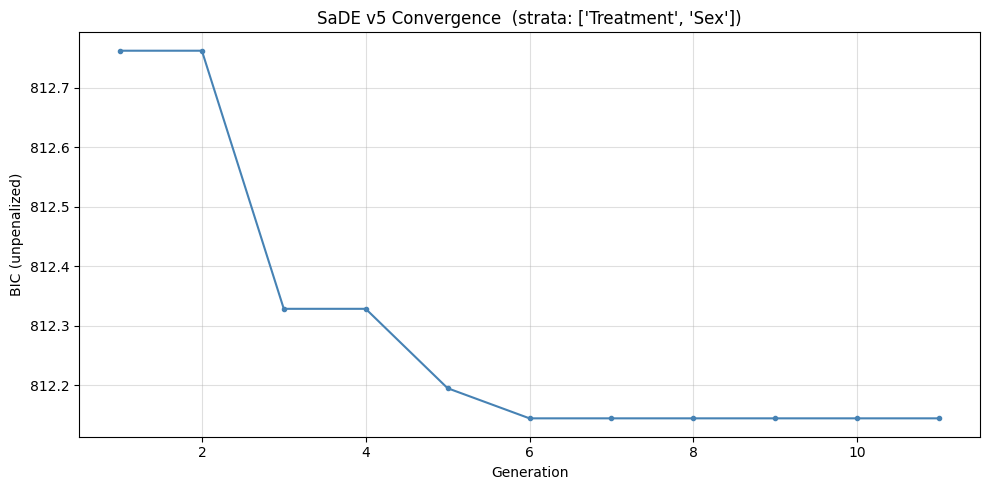


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v5)
----------------------------------------------------------------------------
Concordance index         |                 0.6454 |                 0.6454
BIC (unpen, n_events)     |                 815.62 |                 812.14
IBS (train, optimistic)   |                 0.1233 |                 0.1211
Log-lik (unpen)           |              -405.3373 |              -401.1236
Parameters (k)            |                      1 |                      2
  * Both models stratified on: ['Treatment', 'Sex']

  Covariate scales (divide raw values by these before scoring new data):
    Age: ÷10

FP Cox model summary (Simulated):


model,lifelines.CoxPHFitter
duration col,'Time'
event col,'Event'
penalizer,0.01
l1 ratio,0.0
strata,"[Treatment, Sex]"
baseline estimation,breslow
number of observations,200
number of events observed,141
partial log-likelihood,-407.72
time fit was run,2026-03-20 16:55:55 UTC


Starting SaDE v5  (gamma=0.0)
  FP covariates : ['PatientAge', 'LogNodes']
  Scales applied: PatientAge÷10, LogNodes÷0.1
  n=305, n_events=81  (BIC uses n_events)
  Pop size      : 32  |  Max gens : 15  |  Budget : 480 evals
  lp (adapt)    : every 3 gens  |  patience (stop) : 5 gens
  Objective     : BIC(unpenalized) only
  Early stop at gen 5 (no improvement for 5 gens, evals used: 192)

--- Optimal Power Selection ---
  PatientAge            : p1=0.5     p2=None
  LogNodes              : p1=0.5     p2=None

  Best objective : 767.5229
  Generations    : 5
  Evaluations    : 192  (cache hits: 21)


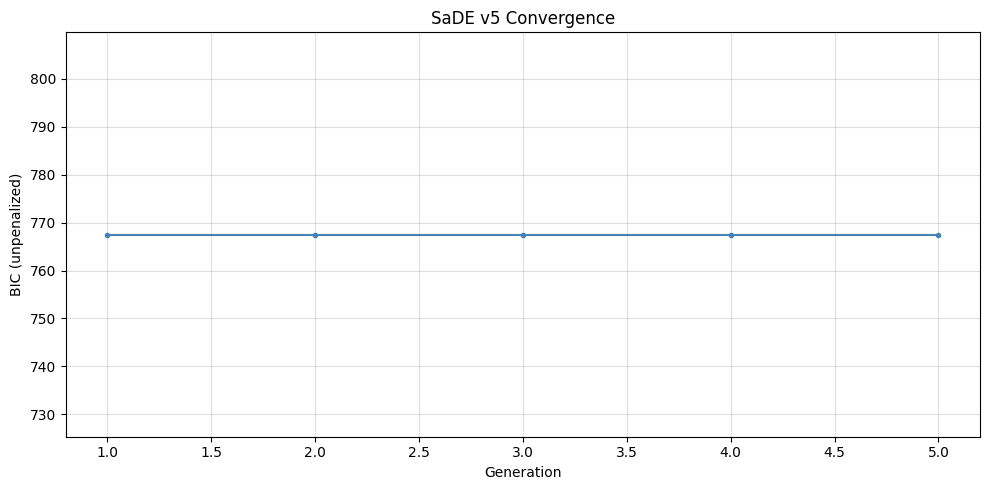


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v5)
----------------------------------------------------------------------------
Concordance index         |                 0.6682 |                 0.6710
BIC (unpen, n_events)     |                 768.78 |                 767.52
IBS (train, optimistic)   |                 0.1598 |                 0.1599
Log-lik (unpen)           |              -379.9943 |              -379.3670
Parameters (k)            |                      2 |                      2

  Covariate scales (divide raw values by these before scoring new data):
    PatientAge: ÷10
    LogNodes: ÷0.1

FP Cox model summary (Haberman):


<lifelines.CoxPHFitter: fitted with 305 total observations, 224 right-censored observations>
             duration col = 'PatientYearOperation'
                event col = 'SurvivalStatus'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 305
number of events observed = 81
   partial log-likelihood = -379.88
         time fit was run = 2026-03-20 16:56:02 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
PatientAge_fp_0.5  0.53      1.70      0.49           -0.42            1.49                0.65                4.42
LogNodes_fp_0.5    0.26      1.29      0.05            0.15            0.36                1.16                1.44

                   cmp to    z      p  -log2(p)
covariate                                      
PatientAge_fp_0.5    0.00 1.09   0.28      1.86
LogNodes_fp_0.5      0.00 4.78 <0.005     19.15
---
Concordance = 0.67
Partial AIC = 763.75
log-likelihood ratio test = 24.88 on 2 df
-log2(p) of ll-ratio test = 17.95

Starting SaDE v5  (gamma=0.0)
  FP covariates : ['log_pgr', 'log_nodes', 'log_er', 'age', 'size']
  Strata        : ['meno', 'grade', 'hormon']
  Scales applied: log_pgr÷1, log_nodes÷1, log_er÷1, age÷10, size÷10
  n=686, n_events=299  (BIC uses n_events)
  Pop size      : 80  |  Max gens : 15  |  Budget : 1200 evals
  lp (adapt)    : every 3 gens  |  patience (stop) : 5 gens
  Objective     : BIC(unpenalized) only
  Early stop at gen 8 (no improvement for 5 gens, evals used: 720)

--- Optimal Power Selection ---
  log_pgr               : p1=1       p2=None
  log_nodes             : p1=0       p2=-2
  log_er                : p1=1.5     p2=None
  age                   : p1=-2.5    p2=-1.5
  size                  : p1=-2      p2=-1
  Stratified on : ['meno', 'grade', 'hormon']

  Best objective : 2262.1304
  Generations    : 8
  Evaluations    : 720  (cache hits: 68)


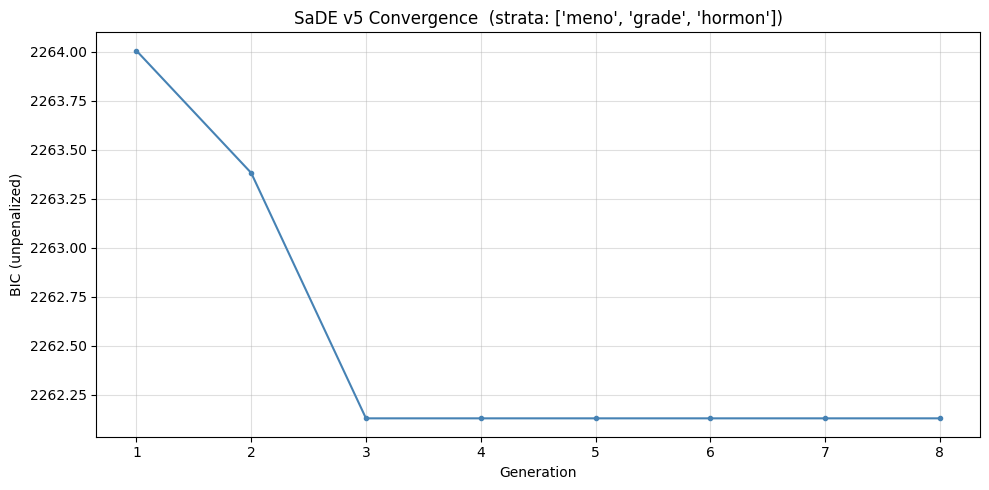


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v5)
----------------------------------------------------------------------------
Concordance index         |                 0.6673 |                 0.6822
BIC (unpen, n_events)     |                2266.30 |                2262.13
IBS (train, optimistic)   |                 0.2278 |                 0.2318
Log-lik (unpen)           |             -1118.9001 |             -1108.2634
Parameters (k)            |                      5 |                      8
  * Both models stratified on: ['meno', 'grade', 'hormon']

  Covariate scales (divide raw values by these before scoring new data):
    log_pgr: ÷1
    log_nodes: ÷1
    log_er: ÷1
    age: ÷10
    size: ÷10

FP Cox model summary (GBSG):


model,lifelines.CoxPHFitter
duration col,'rfstime'
event col,'status'
penalizer,0.01
l1 ratio,0.0
strata,"[meno, grade, hormon]"
baseline estimation,breslow
number of observations,686
number of events observed,299
partial log-likelihood,-1113.49
time fit was run,2026-03-21 00:56:04 UTC


In [ ]:
import pandas as pd

# ---- Dataset 1: Simulated ----
sd_df = pd.read_csv('C:/Users/RASHMIKA/Desktop/4th/research/New folder/CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_simulated_data.csv')
optimizer_sd = FPCoxOptimizer(
    df           = sd_df,
    covariates   = ['Age'],
    duration_col = 'Time',
    event_col    = 'Event',
    strata_cols  = ['Treatment', 'Sex'],
    gamma        = 0.0,
)
optimizer_sd.optimize(maxiter=15, popsize=8, seed=42)
print('\nFP Cox model summary (Simulated):')
optimizer_sd.final_fp_model.print_summary()

# ---- Dataset 2: Haberman ----
hm_df = pd.read_csv('C:/Users/RASHMIKA/Desktop/4th/research/New folder/CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_haberman.csv')
optimizer_hm = FPCoxOptimizer(
    df           = hm_df,
    covariates   = ['PatientAge', 'LogNodes'],
    duration_col = 'PatientYearOperation',
    event_col    = 'SurvivalStatus',
    gamma        = 0.0,
)
optimizer_hm.optimize(maxiter=15, popsize=8, seed=42)
print('\nFP Cox model summary (Haberman):')
optimizer_hm.final_fp_model.print_summary()

# ---- Dataset 3: GBSG ----
# log_er is present in preprocess_gbsg.csv — included as a covariate.
gb_df = pd.read_csv('C:/Users/RASHMIKA/Desktop/4th/research/New folder/CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_gbsg.csv')
GB_COVARIATES = ['log_pgr', 'log_nodes', 'log_er', 'age', 'size']
GB_STRATA     = ['meno', 'grade', 'hormon']
optimizer_gb = FPCoxOptimizer(
    df           = gb_df,
    covariates   = GB_COVARIATES,
    duration_col = 'rfstime',
    event_col    = 'status',
    strata_cols  = GB_STRATA,
    gamma        = 0.0,
)
optimizer_gb.optimize(maxiter=15, popsize=8, seed=42)
print('\nFP Cox model summary (GBSG):')
optimizer_gb.final_fp_model.print_summary()